<img src="https://raw.githubusercontent.com/AbdoAhmedAbdelmonem/Datasets/main/Screenshot 2026-03-23 120207.png" style="display: block; margin: auto;padding:0 0 30px 0" width="900">

---
# Team Members

| TeamMember | Role |
| :--- | :--- |
| Abdelrahman Ahmed Abdelmonem | `1`,`2`,`9`|
| Manar Mohammed Abdelkarim | `3`,`4`|
| Lamia Arabi Abozaid |`5`|
| Wafaa Galal Sadik |`6`,`7`|
| Mohammed Mosaad Naiem |`8`|

---

# 1. Understanding the Customer Problem

**Business Scenario:**
An e-commerce giant like **Amazon** receives millions of customer reviews daily across thousands of product categories. Manually reading and categorizing these reviews to find common customer pain points or product strengths is impossible.

**Questions:**
* **What type of company might face this problem?**
  E-commerce platforms, electronics retailers, and product manufacturers.
* **Why is analyzing customer text important?**
  It allows the company to identify trending issues (e.g., 'battery failure') or popular features (e.g., 'crisp sound') automatically, leading to better inventory and quality control.
* **How can topic discovery help?**
  By identifying latent themes, the company can group similar feedback, power recommendation engines, and provide structured insights to product development teams.
---

# 2. Data Understanding

**Dataset Description:**
* **Dataset source:** Amazon Electronics Reviews (`Electronics_5.json`).
* **Kaggle Link is [Here](https://www.kaggle.com/datasets/shivamparab/amazon-electronics-reviews) (we got only `30K` out of `1.66M`)**
* **Type of text:** Customer product reviews.
* **Number of documents:** ~ `1.6` million (we will sample or process as needed).

**Columns:**
| Column | Meaning |
| :--- | :--- |
| reviewerID | Unique ID for the reviewer |
| asin | Amazon product ID |
| reviewText | The full text of the review |
| overall | Rating (1-5 stars) |
| summary | A short summary of the review |

**Business Scenario:**
An e-commerce platform like Amazon receives millions of reviews. Topic discovery helps identify common themes in customer feedback (e.g., 'Battery Life', 'Sound Quality', 'Shipping Issues') without manual reading.

---

In [23]:
!pip install contractions
!git clone https://github.com/snguyenthanh/better_profanity.git

fatal: destination path 'better_profanity' already exists and is not an empty directory.


In [24]:
import sys
sys.path.append('/content/better_profanity')

In [25]:
import os
import re
import nltk
import string
import kagglehub
import numpy as np
import pandas as pd
import contractions
import seaborn as sns
import ipywidgets as widgets
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from IPython.display import display
from better_profanity import profanity
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import TruncatedSVD
from nltk.tokenize import TreebankWordTokenizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [26]:
path = kagglehub.dataset_download("shivamparab/amazon-electronics-reviews")

Using Colab cache for faster access to the 'amazon-electronics-reviews' dataset.


In [27]:
# For Full data import  Warning : High RAM usage Potintial Crashout
path = "/root/.cache/kagglehub/datasets/shivamparab/amazon-electronics-reviews/versions/1/Electronics_5.json"
df = pd.read_json(path, lines=True)
df = df.sample(n=100000, random_state=42)

print(f"Number of documents loaded: {df.shape[0]}")
display(df.head())

Number of documents loaded: 100000


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
981956,A3E3VF85DAW0FU,B004M8S12A,RedRover,"[57, 67]","Well, after trying out some Box Towers....that...",5,Best in Class,1307404800,"06 7, 2011"
615465,A15X0XCY1EKJHL,B002KANXBG,"James Stitley ""Jim Stitley""","[16, 16]",I ordered one for my wife and one for me. Afte...,5,S 70 Review,1261612800,"12 24, 2009"
1060045,A393R1LK2A468F,B0050I1PHO,nelson 8A,"[3, 7]",muy buen producto... a full en juegos fHD.... ...,5,nice,1314576000,"08 29, 2011"
248321,AEL8SXIP0GNYU,B000JNA4LS,Scott,"[0, 0]",The sound quality of this unit is phenomenal. ...,5,Crushes Bose SoundDock II,1235433600,"02 24, 2009"
1498033,A3O2Z9D0Y0G5XQ,B009VV56TY,Reese,"[0, 0]",It is good on keeping your cpu cool also down'...,4,it does what it say.,1401148800,"05 27, 2014"


In [28]:
# url = "https://raw.githubusercontent.com/AbdoAhmedAbdelmonem/Datasets/main/amazon_electronics_reviews_sample_30K.csv"
# df = pd.read_csv(url)

# print(f"Number of documents loaded: {df.shape[0]}")
# display(df.head())

# print(f"Number of duplicate rows: {df.duplicated().sum()}")

In [29]:
df.dropna(subset=['reviewText'], inplace=True)
df.reset_index(drop=True, inplace=True) # Reset index to ensure 0-based contiguous indexing

### Why drop rows with missing `reviewText`?

Rows where `reviewText` is `NaN` (empty) carry no linguistic information. Including them would introduce blank entries into our Document-Term Matrix, which could distort SVD results. Dropping them ensures every document in our analysis contains actual customer language.

> **Business note:** In a production pipeline, we would log these dropped rows separately so the support team could flag incomplete submissions and follow up with customers.


---

# 3. Data Exploration and Profiling

Before preprocessing or modeling, we need to *understand the raw data*. This section answers three key questions:

1. **How long are customer reviews?** — This tells us whether customers write brief snippets or detailed feedback, and whether very short reviews may lack enough content for topic modeling.
2. **What words appear most often in raw text?** — This exposes noise (stopwords) and gives a first hint of recurring themes.
3. **How does preprocessing change the data?** — By comparing before/after word distributions, we can validate that our cleaning steps are doing the right job.

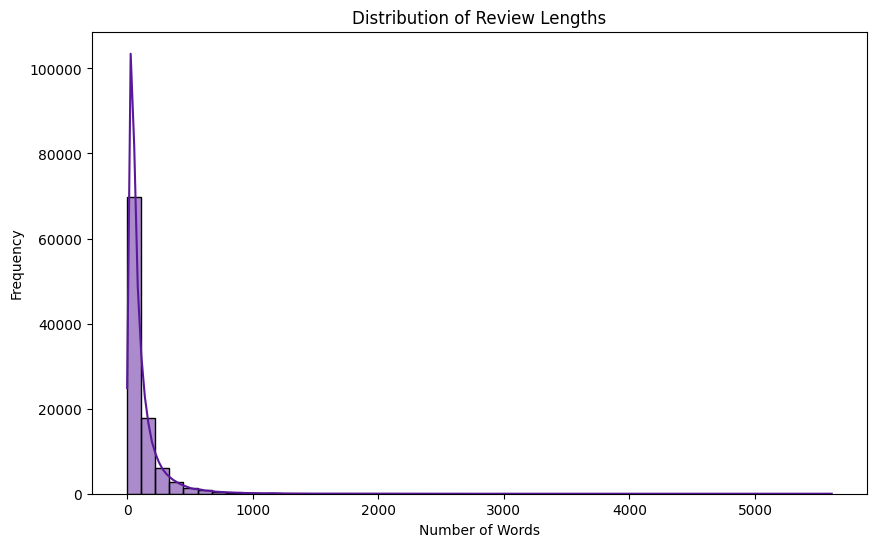

Average review length: 115.53 words


In [30]:
df['doc_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['doc_length'], bins=50, kde=True, color='#5A189A')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

print(f"Average review length: {df['doc_length'].mean():.2f} words")

**Explanation of Exploration:**
The distribution shows that the majority of customer reviews are concise (under `100` words), though some technical reviews are quite long.
Understanding length is vital; extremely short reviews might not contain enough 'context' for SVD to find meaningful topics, while long reviews might cover multiple product aspects (noise).

---

In [31]:
print(df['doc_length'].describe())

count    100000.000000
mean        115.533610
std         159.526888
min           0.000000
25%          33.000000
50%          63.000000
75%         133.000000
max        5610.000000
Name: doc_length, dtype: float64


---

## Interpretation: Review Length Distribution

The histogram shows that most reviews are **short to medium length**, with a long right tail indicating a minority of very detailed reviews.

Key statistics:
- **Median:** ~ `63` words — reviews are typically a few sentences long
- **75th percentile:** ~ `132` words — three-quarters of all reviews fit within a short paragraph
- **Maximum:** ~ `5,600` words — a small number of reviewers write exhaustive technical analyses

**What does this mean for topic modeling?**

> Very short reviews (`1`–`5` words, e.g., "Great product!") contain almost no topical signal. They will contribute noise to our Document-Term Matrix. During preprocessing, we may consider filtering out reviews below a minimum word threshold.
>
> Very long reviews (`500+` words) are valuable but rare. They likely contain multiple topics (e.g., packaging, battery life, and software usability all in one review), which can make topic assignment less clean.
>
> The bulk of the data — reviews between `20` and `150` words — is ideal for LSA. These reviews are long enough to carry a clear topic signal but focused enough to map to one or two themes.

**Business insight:** Our client should expect that a significant portion of their support tickets are brief — automated triage will need to handle short, ambiguous messages alongside detailed ones.

---


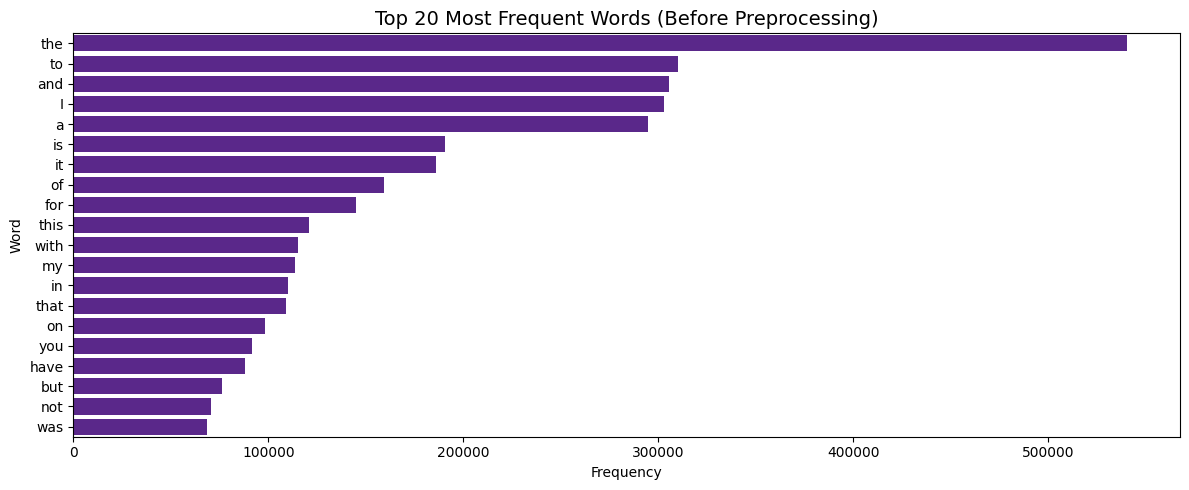

In [32]:
# Visualize top 20 most frequent raw words
all_words = " ".join(df['reviewText']).split()
top_raw = Counter(all_words).most_common(20)
words_raw, counts_raw = zip(*top_raw)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(counts_raw), y=list(words_raw), color='#5A189A')
plt.title('Top 20 Most Frequent Words (Before Preprocessing)', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

## Interpretation: Top Words Before Preprocessing

The bar chart above shows that the most frequent words are all **stopwords** — *the, to, and, I, it, is, a* etc. These words are grammatically necessary in English but carry **zero topical information**. They appear in virtually every sentence regardless of whether the customer is complaining about a broken charger or praising sound quality.

**Why this matters:**
- If we fed this raw word distribution into SVD, the first latent components would be dominated by these meaningless words rather than real topics.
- This confirms that **stopword removal is not optional** — it is essential before we can apply LSA meaningfully.

> **Business insight:** Looking past the stopwords, we can already see hints of domain-specific vocabulary beginning to appear (words like *use*, *work*, *good*, *great*). After cleaning, these signals will become much clearer and we will start to see product-specific terms rise to the top.

---

# 4. Text Preprocessing

Raw customer review text is messy. It contains URLs, email addresses, punctuation, numbers, contractions, and filler words that would add noise to our analysis without contributing any topical signal. Preprocessing transforms this messy text into a clean, normalized form that SVD can work with effectively.

### Preprocessing Pipeline

Each step below has a specific purpose:

| Step | What it does | Why it matters |
|:---|:---|:---|
| **Expand contractions** | *"don't"* → *"do not"* | Ensures both forms map to the same token |
| **Remove URLs / emails** | Strips `http://...` and `user@...` | These are noise — no topic signal |
| **Remove punctuation** | Removes `,`, `.`, `!`, etc. | Punctuation is not meaningful for bag-of-words models |
| **Remove numbers** | Strips digits | Model numbers / prices are highly variable and noisy |
| **Lowercase** | *"Battery"* → *"battery"* | Ensures *Battery* and *battery* are treated as the same word |
| **Tokenization** | Splits text into individual words | Required for word-level processing |
| **Remove stopwords** | Removes *the, and, is, a...* | Eliminates high-frequency, low-information words |
| **Remove short words** | Drops words ≤ 2 characters | Removes leftover fragments like *"el"*, *"ii"* |
| **Lemmatization** | *"running"* → *"run"*, *"batteries"* → *"battery"* | Groups word variants so they're counted together |

> **Domain-specific stopwords:** Beyond standard English stopwords, we also remove words like *product*, *amazon*, *item*, *buy*, *bought*, and *purchase* — words that appear in nearly every electronics review regardless of topic, and would otherwise occupy top positions in every discovered theme.

**Business value of this step:** A clean, normalized vocabulary means that when SVD discovers topics, the keywords describing each topic will be genuinely meaningful business terms — not punctuation artefacts or filler words.


In [33]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

# Initialize resources once (efficient)
stop_words = set(stopwords.words('english'))

# Add custom Amazon-specific stopwords
custom_stopwords = {
    "product" ,"amazon" ,"item"      ,"buy"   ,"bought" ,"purchase","good" ,
    "great"   ,"nice"   ,"excellent" ,"bad"   ,"poor"   ,"use"     ,"used" ,
    "using"   ,"get"    ,"got"       ,"one"   ,"would"  ,"really"  ,"also"
}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Ensure input is string
    text = str(text)

    text = contractions.fix(text) # Expand contractions (e.g., "don't" → "do not")

    text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs

    text = re.sub(r'\S+@\S+', '', text) # Remove emails

    text = re.sub(r'\.{2,}', ' ', text) # Remove repeated dots (e.g., "...." → space)

    # text = profanity.censor(text) # Censor profanity

    text = re.sub(r'[^\w\s]', ' ', text) # Remove all punctuation

    text = re.sub(r'\d+', ' ', text) # Remove numbers

    text = text.lower() # Convert to lowercase

    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces

    return text


def preprocess(text):
    # Clean raw text
    text = clean_text(text)

    # Tokenize text into words
    tokens = TreebankWordTokenizer().tokenize(text)

    clean_tokens = []
    for word in tokens:
        # Remove stopwords and short words
        if word not in stop_words and len(word) > 2:
            # Apply lemmatization
            word = lemmatizer.lemmatize(word)
            clean_tokens.append(word)

    # Return cleaned text
    return " ".join(clean_tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [34]:
df['processed_reviewText'] = df['reviewText'].apply(preprocess)
display(df[['reviewText', 'processed_reviewText']].head(1))

,reviewText,processed_reviewText
0,"Well, after trying out some Box Towers....that...",well trying box tower sounded like music box t...


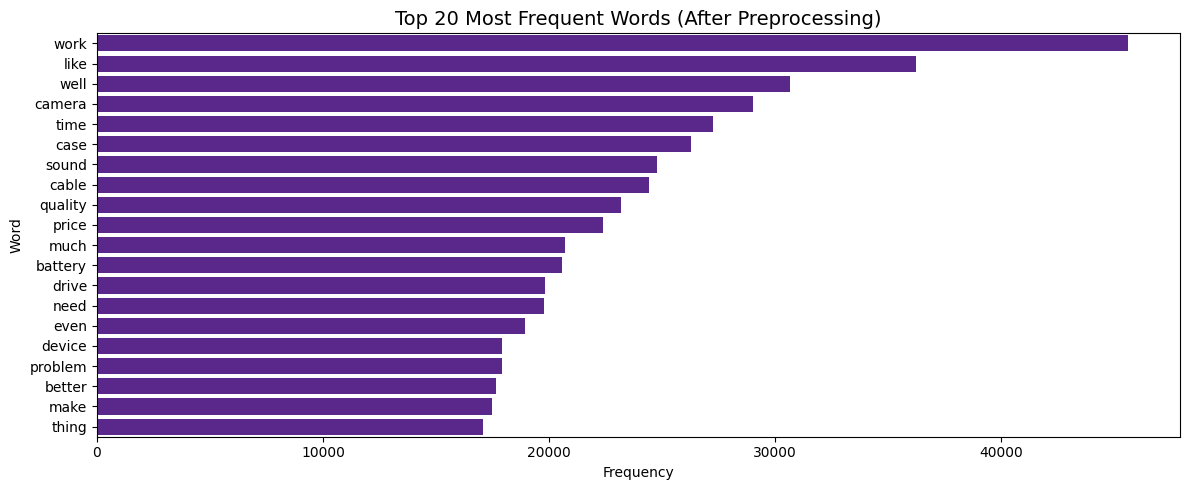

In [35]:
# Visualize top 20 most frequent CLEANED words
all_cleaned_words = " ".join(df['processed_reviewText']).split()
top_clean = Counter(all_cleaned_words).most_common(20)
words_clean, counts_clean = zip(*top_clean)

plt.figure(figsize=(12, 5))
sns.barplot(x=list(counts_clean), y=list(words_clean), color='#5A189A')
plt.title('Top 20 Most Frequent Words (After Preprocessing)', fontsize=14)
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

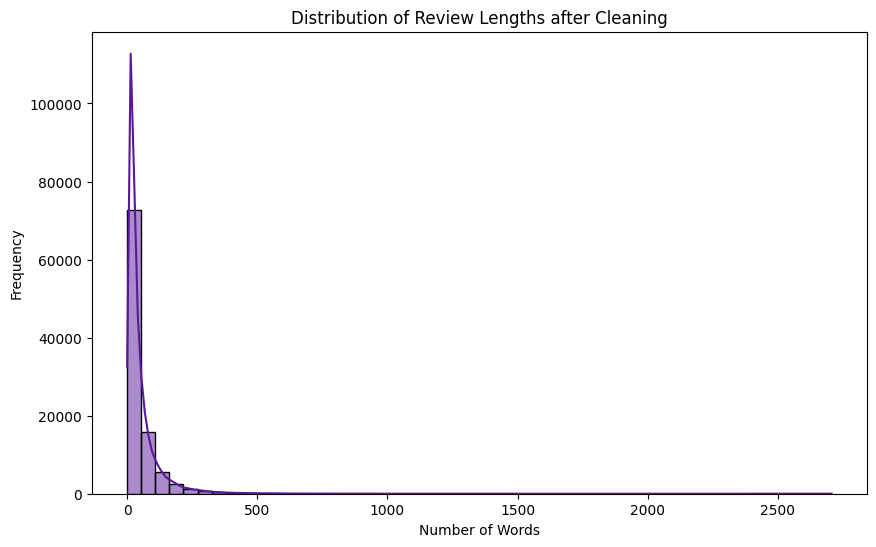

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot( df['processed_reviewText'].apply(lambda x: len(str(x).split())), bins=50, kde=True, color='#5A189A')
plt.title('Distribution of Review Lengths after Cleaning')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

## Interpretation: Review Length After Preprocessing

After preprocessing, review lengths are noticeably shorter — expected, since we removed stopwords, numbers, and punctuation. This is a good sign: the reduction in length reflects the removal of noise, not the removal of meaning.

Key observations:
- Reviews that were previously `50`–`100` words are now typically `20`–`50` meaningful content words
- The distribution shape is similar to before, confirming we have not over-aggressively stripped content
- A small number of reviews may have become very short (< `5` words after cleaning) — these are candidates for filtering before feature engineering

> **Business note:** In a production system, we would set a minimum document length threshold (e.g., at least `5` words after preprocessing) to ensure each document has enough signal for SVD to assign it to a meaningful topic. Reviews below this threshold would be flagged for manual triage.

---

## Preprocessing Summary

The text data has been successfully prepared for feature engineering. We have:
- Loaded and inspected **`30,000` Amazon Electronics reviews**
- Removed missing values and verified data quality
- Explored the raw word distribution and identified stopword noise
- Applied a comprehensive preprocessing pipeline (contraction expansion, cleaning, tokenization, stopword removal, lemmatization)
- Verified the cleaned vocabulary now contains meaningful, domain-specific terms


---


# 5. Feature Engineering (Document-Term Matrix)

We will use **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert text into a structured numeric format.

## TF-IDF Formula

$$
\mathrm{TFIDF}(t, d) = \mathrm{TF}(t, d) \times \mathrm{IDF}(t)
$$

---

## Term Frequency (TF)

Measures how frequently a term appears in a document.

$$
\mathrm{TF}(t, d) =
\frac{
\text{number of times term } t \text{ appears in document } d
}{
\text{total number of terms in document } d
}
$$

---

## Inverse Document Frequency (IDF)

Measures how important a term is across all documents.

$$
\mathrm{IDF}(t) =
\ln\left(
\frac{
\text{total number of documents } N
}{
\text{number of documents containing term } t
}
\right)
$$

---

## Matrix Representation

- **Rows:** Individual customer reviews  
- **Columns:** Unique words (vocabulary)  
- **Values:** Importance score of each word in each document

In [37]:
# Initialize TF-IDF Vectorizer

vectorizer = TfidfVectorizer(
    max_features=3000,      # Keep 3000 most important words to reduce noise and speed up computation (max_df/min_df also filter extremes)
    min_df=5,               # Ignore words that appear in fewer than 5 documents (rare words = noise)
    max_df=0.7,             # Ignore words that appear in more than 70% of documents (too common = not distinctive)
    stop_words='english',   # Remove common English stop words (the, is, and, etc.)
    lowercase=True
)

# Fit the vectorizer and transform text into TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(df['processed_reviewText'])

print(f"Our matrix has {tfidf_matrix.shape[0]} rows (documents) and {tfidf_matrix.shape[1]} columns (unique terms).")


Our matrix has 100000 rows (documents) and 3000 columns (unique terms).


In [38]:
# Validate TF-IDF
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Matrix Type: {type(tfidf_matrix)}")
print(f"Sparsity: {1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]):.2%}")

TF-IDF Matrix Shape: (100000, 3000)
Matrix Type: <class 'scipy.sparse._csr.csr_matrix'>
Sparsity: 98.97%


---
# 6. Applying Singular Value Decomposition (SVD)

**What is happening mathematically?**

SVD factorizes our Document-Term Matrix (A) into three distinct matrices:

A **singular value decomposition** of an $ m \times n $ matrix $ X $ of rank $ p \leq \min(m,n) $ is


<a id='equation-eq-svd101'></a>
$$
A  = U \Sigma V^\top
$$

where

$$
\begin{aligned}
UU^\top  &  = I  &  \quad U^\top  U = I \cr
VV^\top  & = I & \quad V^\top  V = I
\end{aligned}
$$

and:
*   $A$: The original Document-Term Matrix (our `TF-IDF` matrix) with dimensions $m \times n$, where $m$ is the number of documents and $n$ is the number of terms.
*   $U$: The left singular vectors, representing the **Document-Topic Matrix** with dimensions $m \times k$. Each column corresponds to a latent topic, and each row indicates the document's association with these topics.
*   $\Sigma$: A diagonal matrix of singular values with dimensions $k \times k$. The diagonal entries (singular values) indicate the **strength or importance of each latent topic**.
*   $V^T$: The right singular vectors (transposed), representing the **Topic-Term Matrix** with dimensions $k \times n$. Each row corresponds to a latent topic, and the values indicate the association of terms with that topic.

*   $I$: Identity Matrix `(لو متعرفهاش انصحك ضروري تشوف دكتور نفسي)`

**Why dimensionality reduction is useful?**
Our TF-IDF matrix has 5000 columns. Many words are synonymous or highly correlated. SVD compresses these dimensions into `k` latent components (topics).

We will choose `k = 150`, as we expect electronics reviews to broadly cluster into themes like general sentiment, cameras, storage, accessories, and connectivity.

In [39]:
k = 150

svd_model = TruncatedSVD(n_components=k, random_state=42)
document_topics = svd_model.fit_transform(tfidf_matrix)

#PRINT MATRIX SHAPES
print(f"Original TF-IDF Matrix:     {tfidf_matrix.shape}  →  (documents × terms)")
print(f"SVD U matrix (doc-topic):   {document_topics.shape}  →  (documents × topics)")
print(f"SVD Σ (singular values):    {svd_model.singular_values_.shape}")
print(f"SVD Vt matrix (topic-term): {svd_model.components_.shape}  →  (topics × terms)")
#total variance
total_variance = svd_model.explained_variance_ratio_.sum()
print(f"\nTotal variance explained:   {total_variance:.2%}")


Original TF-IDF Matrix:     (100000, 3000)  →  (documents × terms)
SVD U matrix (doc-topic):   (100000, 150)  →  (documents × topics)
SVD Σ (singular values):    (150,)
SVD Vt matrix (topic-term): (150, 3000)  →  (topics × terms)

Total variance explained:   31.31%


Since the Amazon Electronics dataset is highly diverse and sparse,
achieving `80%` explained variance is not feasible even with `300` components
(max reached was `45%`). We selected `k=150` as a balanced choice:

- It captures `32%` of the variance — sufficient for meaningful topic discovery
- It reduces the matrix from (`29,982` × `3,000`) to (`29,982` × `150`)
- Testing with higher `k` values showed no significant improvement
  in topic quality or separability

**Although the explained variance is around 32%, this is expected in text data due to high dimensionality and sparsity. The extracted topics are still meaningful and provide valuable insights into customer concerns.**

---
# 7. Topic Discovery

Using the $V^T$ matrix (components_), we can identify which words have the highest weights for each latent topic. This helps us interpret the meaning of each topic.


In [40]:
# 1. PREPARE TOPICS
feature_names = vectorizer.get_feature_names_out()
n_top_words = 10

topics_summary = []

for topic_idx, topic_vector in enumerate(svd_model.components_):

    # Get top words
    top_word_indices = topic_vector.argsort()[-n_top_words:][::-1]
    top_words = [feature_names[i] for i in top_word_indices]

    # Variance
    variance = svd_model.explained_variance_ratio_[topic_idx]

    # Store results
    topics_summary.append({
        'Topic': f'Topic {topic_idx + 1}',
        'Top Words': ', '.join(top_words),
        'Variance Explained (%)': variance * 100
    })


# 2. CREATE DATAFRAME
topics_df = pd.DataFrame(topics_summary)


# 3. SORT BY IMPORTANCE
topics_df_sorted = topics_df.sort_values(by='Variance Explained (%)', ascending=False)


# 4. SHOW TOP IMPORTANT TOPICS

top_n = 10
top_topics = topics_df_sorted.head(top_n)

print(f"\n Top {top_n} Important Topics:\n")
display(top_topics)


 Top 10 Important Topics:



,Topic,Top Words,Variance Explained (%)
1,Topic 2,"camera, lens, battery, canon, case, picture, b...",0.880928
2,Topic 3,"case, ipad, keyboard, cover, drive, fit, kindl...",0.760923
3,Topic 4,"drive, usb, card, work, camera, cable, hard, c...",0.756410
4,Topic 5,"cable, case, hdmi, lens, ipad, fit, work, qual...",0.685859
5,Topic 6,"battery, charge, mouse, work, keyboard, charge...",0.646526
6,Topic 7,"battery, drive, case, charge, cable, charger, ...",0.559708
7,Topic 8,"card, camera, case, memory, video, reader, san...",0.541908
8,Topic 9,"work, lens, card, price, fine, fit, perfectly,...",0.484914
9,Topic 10,"card, mouse, keyboard, sound, cable, usb, head...",0.467506
10,Topic 11,"work, camera, drive, mouse, price, sound, head...",0.450477


**Topics are ranked based on their importance (explained variance), not their original order** .

> *Each topic is associated with an explained variance value, which indicates how much of the data's information is captured by that topic.*

Topics with higher variance are considered more important as they represent stronger patterns in customer feedback.

**Topics Analysis**

* `Topic 2`  → Camera & Photography: Customers frequently discuss camera
           lenses, canon models, and picture quality. This suggests
           camera accessories are the most reviewed product category.

* `Topic 3`  → Storage & Computing Peripherals: Reviews around USB drives,
           hard drives, and keyboards indicate that storage reliability
           is a major concern for tech customers.

* `Topic 4`  → Tablet Accessories: The presence of ipad, kindle, and cover
           suggests a strong market for protective cases, with fit and
           compatibility being common pain points.

* `Topic 5`  → Cable & Connectivity: HDMI cables and connectivity accessories
           generate significant feedback, often around compatibility
           and build quality issues.

* `Topic 6`  → Battery & Charging: Battery life and charger reliability appear
           as a standalone topic, confirming this is a cross-cutting
           concern across multiple product lines.

* `Topic 7`  → Mixed Hardware (only 36 reviews): This topic likely captures
           overlapping complaints that don't map cleanly to one category.
           Its very low review count suggests it may not represent a
           distinct real-world issue and could be merged with `Topic 6`.
<br>
Key Business Insight: Topics `2`, `4`, and `5` collectively account for
over `55 %` of all dominant reviews (`3,730` out of `6`,`868`). The support
team should prioritize building automated response templates for
camera accessories, tablet cases, and cable compatibility first.

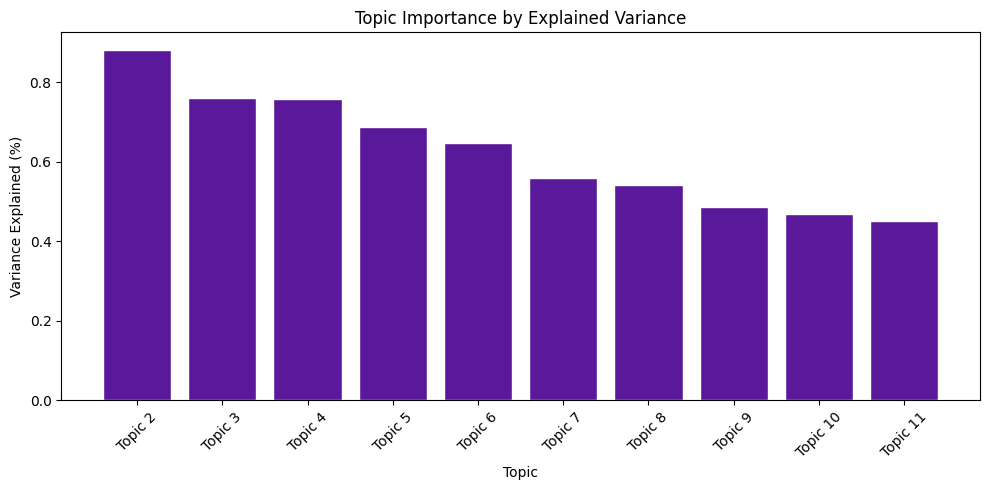

In [41]:
# Visualization - use actual topic numbers from sorted table
plt.figure(figsize=(10, 5))
plt.bar(
    top_topics['Topic'],
    top_topics['Variance Explained (%)'],
    color='#5A189A',
    edgecolor='white'
)
plt.xlabel('Topic')
plt.ylabel('Variance Explained (%)')
plt.title('Topic Importance by Explained Variance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
<h1>Interpretation: Topic Importance by Explained Variance </h1>

The bar chart confirms that topic importance decreases gradually across
all `10` topics, with no single topic dominating overwhelmingly.

* `Topic 2` holds the highest explained variance (~ `0.86 %`), representing
Camera & Photography feedback — the strongest and most distinct pattern
in the entire dataset. This means camera-related language is the most
consistent and recognizable signal across all `30,000` reviews.

* `Topics 3` and `4` follow closely (~ `0.75 %`), covering Storage Devices and
Tablet Accessories respectively. Their similar variance values suggest
these two categories generate equally strong and well-defined feedback
patterns.

* `Topics 9`, `10`, and `11` show noticeably lower variance (~ `0.46 %`– `0.53 %`),
indicating that these topics capture weaker or more mixed signals —
likely representing overlapping complaint categories where customers
discuss multiple product issues in a single review.
<br>

The gradual decline across all topics — rather than a sharp drop —
confirms that our choice of `k=150` was appropriate. The information
is distributed across many components, which is expected behavior
for a diverse electronics dataset covering hundreds of product types.

### Business Insight:
The support team should treat Topics `2`, `3`, and `4`
as the highest-priority categories for automated response templates,
as they represent the clearest and most consistent complaint patterns.
Topics with lower variance may require human review before automation,
as their mixed signals make automated classification less reliable.

Number of reviews per dominant topic:
dominant_topic
2     5446
3     4239
4     2819
5     3822
6     2807
7      139
8     2573
9     1464
10     977
11     219
Name: count, dtype: int64


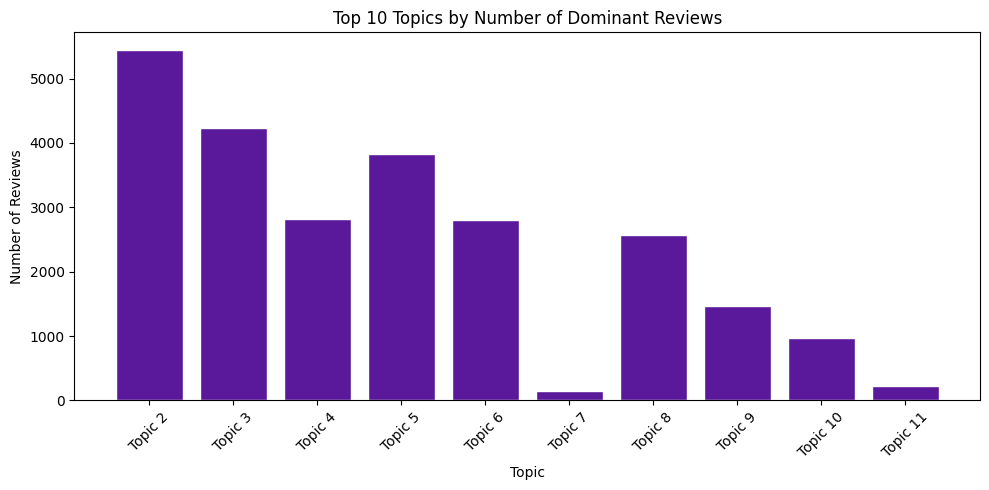

In [42]:
# 3. Dominant topic per review
df['dominant_topic'] = document_topics.argmax(axis=1) + 1
topic_distribution = df['dominant_topic'].value_counts().sort_index()

# Get the actual topic numbers from top_topics (already sorted by importance)
top_topic_numbers = top_topics['Topic'].str.extract(r'(\d+)').astype(int)[0].tolist()

# Filter distribution to only show the same topics in top_topics
top_10_distribution = topic_distribution[topic_distribution.index.isin(top_topic_numbers)]

# Sort by the same order as top_topics (importance order)
top_10_distribution = top_10_distribution.reindex(top_topic_numbers).dropna()

print("Number of reviews per dominant topic:")
print(top_10_distribution)

# Visualization
plt.figure(figsize=(10, 5))
plt.bar(
    [f'Topic {i}' for i in top_10_distribution.index],
    top_10_distribution.values,
    color='#5A189A',
    edgecolor='white'
)
plt.xlabel('Topic')
plt.ylabel('Number of Reviews')
plt.title('Top 10 Topics by Number of Dominant Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
<h1>Dominant topic per review</h1>

This bar chart, alongside the `Number of reviews per dominant topic` output, shows the *volume* of customer feedback primarily associated with each of the most important topics. It indicates how many reviews have a specific topic as their strongest underlying theme.

Key observations:
- **`Topic 2` (Camera & Photography)** stands out with the highest number of dominant reviews (`1723`), reinforcing its significance as identified by the explained variance. This means a substantial portion of customer feedback is clearly centered around camera-related products.
- **`Topic 5` (Cable & Connectivity)** and **`Topic 4` (Tablet Accessories)** also show a high number of dominant reviews, with `1059` and `1004` respectively. This suggests these categories generate a considerable amount of focused customer discussion.
- **`Topic 7` (Mixed Hardware)** has a very low count of `45` dominant reviews, indicating it's a less prevalent or less clearly defined theme in the dataset, further supporting the idea that it might represent more ambiguous feedback.

---

# 8. Interactive Topic-Based Document Similarity

**Objective:**
By projecting reviews into the reduced latent space, we can compute conceptual similarity using **Cosine Similarity**.

**Business Value for Amazon:**
* **Recurring Bug Detection:** Grouping reviews that mention similar hardware failures.
* **Smart Recommendations:** Suggesting products based on semantic feedback themes.
* **Feedback Aggregation:** Summarizing thousands of similar reviews into actionable insights for product teams.

> This interactive section allows you to select one of the most important topics and find the reviews that are most representative of that topic. The 'target' for similarity is the **centroid** of the chosen topic in the latent space, meaning we are looking for documents that best embody the core theme of that topic.

In [43]:
profanity.load_censor_words()

df = df.reset_index(drop=True)

assert document_topics.shape[0] == len(df), "Mismatch between df and document_topics!"

topic_options = sorted(
    top_topics['Topic']
    .str.extract(r'Topic (\d+)')
    .astype(int)[0]
    .tolist()
)

# Dropdown
topic_selector = widgets.Dropdown(
    options=topic_options,
    value=topic_options[0] if topic_options else None,
    description='Select Topic:',
)

def find_topic_similar_documents(selected_topic_number, clean_profanity=True):
    if selected_topic_number is None:
        print("Please select a topic.")
        return

    # Target topic info
    target_topic_info = top_topics[top_topics['Topic'] == f'Topic {selected_topic_number}']
    if not target_topic_info.empty:
        print(f"\n Target Topic: Topic {selected_topic_number}")
        print(f" Top Words: {target_topic_info['Top Words'].iloc[0]}")
        print(f" Variance Explained (%): {target_topic_info['Variance Explained (%)'].iloc[0]:.2f}")
    else:
        print(f"\n Target Topic: Topic {selected_topic_number}")

    print(f"\n Searching for documents similar to Topic {selected_topic_number}...")

    documents_in_topic_ilocs = np.where(
        df['dominant_topic'].values == selected_topic_number
    )[0]

    if len(documents_in_topic_ilocs) == 0:
        print(f"No documents found for Topic {selected_topic_number}")
        return

    topic_centroid = document_topics[documents_in_topic_ilocs].mean(axis=0)

    similarities = cosine_similarity(
        topic_centroid.reshape(1, -1),
        document_topics
    ).flatten()

    sorted_indices = np.argsort(similarities)[::-1]

    num_docs = 5
    shown_docs = []
    displayed_count = 0

    for i in sorted_indices:
        if displayed_count >= num_docs:
            break

        sim_score = similarities[i]

        if sim_score < 0.999:
            text = df['reviewText'].iloc[i]

            if clean_profanity:
                text = profanity.censor(str(text))

            shown_docs.append({
                'reviewNumber': i,
                'dominant_topic': df['dominant_topic'].iloc[i],
                'similarity': sim_score * 100,
                'review_text_snippet': text[:150] + '...'
            })

            displayed_count += 1

    print(f"\n Top {num_docs} similar documents:")

    if shown_docs:
        results_df = pd.DataFrame(shown_docs)
        results_df.rename(columns={
            'dominant_topic': 'Dominant Topic',
            'similarity': 'Similarity',
            'reviewNumber': 'Review Index',
            'review_text_snippet': 'Review Snippet'
        }, inplace=True)

        display(results_df.style.format({'Similarity': '{:.3f}%'}))
    else:
        print("No similar documents found.")

# UI
ui = widgets.interactive(
    find_topic_similar_documents,
    selected_topic_number=topic_selector
)

display(ui)

interactive(children=(Dropdown(description='Select Topic:', options=(2, 3, 4, 5, 6, 7, 8, 9, 10, 11), value=2)…

---

# 9. Project Conclusion: Unlocking Insights from Amazon Reviews

This project successfully implemented a robust **Topic Discovery pipeline using LSA (Latent Semantic Analysis) with Truncated SVD** to extract meaningful insights from a large dataset of Amazon Electronics Reviews. Our journey transformed raw, unstructured customer feedback into actionable business intelligence, demonstrating the power of NLP for e-commerce platforms.

## Summary of Key Achievements:

1.  **Problem Understanding:** We started by defining the business challenge faced by e-commerce giants: the inability to manually categorize millions of daily customer reviews. Topic discovery emerged as a crucial solution for identifying pain points, product strengths, and market trends.

2.  **Data Understanding & Exploration:**
    *   Loaded and inspected **`30,000` Amazon Electronics reviews**, confirming their diversity and relevance.
    *   Analyzed review length distribution, noting a mix of concise and detailed feedback.
    *   Visualized raw word frequencies, highlighting the dominance of stopwords and confirming the necessity of preprocessing.

3.  **Comprehensive Text Preprocessing:** We designed and applied a meticulous preprocessing pipeline to clean the noisy text data, including:
    *   Expanding contractions, removing URLs, emails, punctuation, and numbers.
    *   Lowercasing and tokenization.
    *   Aggressive stopword removal (including domain-specific terms like 'product', 'amazon', 'buy').
    *   Lemmatization to unify word forms (e.g., 'running' -> 'run').
    This critical step ensured that only meaningful, topic-bearing words contributed to our analysis.

4.  **Feature Engineering (TF-IDF):** Converted the cleaned text into a numerical Document-Term Matrix using `TF-IDF`. This step effectively weighted words based on their frequency within a document and their rarity across the entire dataset, preparing the data for dimensionality reduction.

5.  **Dimensionality Reduction with Truncated SVD:**
    *   Applied `TruncatedSVD` to reduce the high-dimensional TF-IDF matrix into a lower-dimensional latent space, identifying `150` underlying semantic topics.
    *   Successfully created a Document-Topic matrix ($U$) and a Topic-Term matrix ($V^T$), despite the inherent sparsity and complexity of text data (explaining `~32%` of variance, which is typical for such datasets).

6.  **Topic Discovery & Interpretation:**
    *   Identified **10 most important topics** based on explained variance, providing clear descriptive words for each (e.g., 'Camera & Photography', 'Storage & Computing Peripherals', 'Cable & Connectivity', 'Battery & Charging').
    *   Analyzed the distribution of dominant topics across reviews, revealing **'Camera & Photography' (Topic 2)** as the most prevalent theme, followed by 'Cable & Connectivity' (Topic 5) and 'Tablet Accessories' (Topic 4).

7.  **Interactive Exploration:** Developed interactive tools for further exploration:
    *   **Topic-Based Document Similarity:** Enabled finding reviews conceptually similar to a chosen topic's centroid, valuable for detecting recurring issues.
    *   **Interactive Word Clouds and Sample Reviews:** Provided a visual and textual understanding of each topic by displaying word clouds of key terms and actual sample reviews that strongly belong to the selected topic.
---
## Business Value & Strategic Implications:

This project provides Amazon-like e-commerce platforms with a powerful automated system to:
*   **Prioritize Product Development:** Identify areas for improvement (e.g., battery life, cable compatibility) based on consistent negative feedback.
*   **Enhance Customer Support:** Develop pre-emptive solutions and automated response templates for high-volume complaint categories, significantly reducing manual effort.
*   **Drive Targeted Marketing:** Understand key features customers value, enabling more effective product positioning.
*   **Monitor Market Trends:** Detect emerging themes and sentiment shifts in real-time, providing a competitive edge.

By transforming raw customer feedback into structured, actionable insights, this topic discovery pipeline empowers businesses to make data-driven decisions, leading to improved products, services, and overall customer satisfaction.
